<div align="center">

# Preprocessing

</div>

# 1. Highpass fitler + Notch filter

In [1]:
import h5py
import numpy as np
import mne
import os

def filter_hdf5_file(h5_path, out_path, highpass=0.5, notch=60):

    with h5py.File(h5_path, "r") as f:
        signals = f["signals"][:]          # (ch, samples)
        fs = f["sampling_rate"][()]
        ch_names = [c.decode() for c in f["channel_names"][:]]
        seizures = f["seizure_intervals"][:]

    # -----------------------------
    # Create MNE object
    # -----------------------------
    info = mne.create_info(
        ch_names=ch_names,
        sfreq=fs,
        ch_types="eeg"
    )

    raw = mne.io.RawArray(signals, info, verbose=False)

    # -----------------------------
    # High-pass filter (0.5 Hz)
    # -----------------------------
    raw.filter(
        l_freq=highpass,
        h_freq=None,
        method="iir",
        iir_params=dict(order=4, ftype="butter"),
        phase="zero",
        verbose=False
    )

    # -----------------------------
    # Notch filter (60 Hz)
    # -----------------------------
    # raw.notch_filter(
    #     freqs=notch,
    #     method="iir",
    #     phase="zero",
    #     iir_params=dict(order=4, ftype="butter"),
    #     verbose=False
    # )

    raw.notch_filter(
    freqs=60,
    phase="zero",
    verbose=False
)
    

    filtered = raw.get_data().astype(np.float32)

    with h5py.File(out_path, "w") as f:
        f.create_dataset(
            "signals",
            data=filtered,
            dtype=np.float32,              # make it explicit
            compression="gzip",
            compression_opts=4,            # good balance
            shuffle=False                  # IMPORTANT for EEG
        )

        f.create_dataset("sampling_rate", data=fs)

        f.create_dataset(
            "channel_names",
            data=np.array(ch_names, dtype="S")
        )

        f.create_dataset("seizure_intervals", data=seizures)

In [2]:
import glob
import os

input_dir = "../Dataset_hdf5_clean"
output_dir = "../Dataset_hdf5_filtered"

# Create output directory if not exists
os.makedirs(output_dir, exist_ok=True)

files = glob.glob(input_dir + "/**/*.h5", recursive=True)

if not files:
    print(f"No .h5 files found in {input_dir}")
else:
    print(f"Found {len(files)} files. Processing...")
    for f in files:
        out = f.replace("Dataset_hdf5", "Dataset_hdf5_filtered")
        
        # Create output subdirectory
        os.makedirs(os.path.dirname(out), exist_ok=True)
        
        try:
            filter_hdf5_file(f, out)
            print(f"✓ Filtered: {os.path.basename(f)}")
        except Exception as e:
            print(f"✗ Error filtering {f}: {e}")

Found 655 files. Processing...
✓ Filtered: chb01_01.h5
✓ Filtered: chb01_02.h5
✓ Filtered: chb01_03.h5
✓ Filtered: chb01_04.h5
✓ Filtered: chb01_05.h5
✓ Filtered: chb01_06.h5
✓ Filtered: chb01_07.h5
✓ Filtered: chb01_08.h5
✓ Filtered: chb01_09.h5
✓ Filtered: chb01_10.h5
✓ Filtered: chb01_11.h5
✓ Filtered: chb01_12.h5
✓ Filtered: chb01_13.h5
✓ Filtered: chb01_14.h5


KeyboardInterrupt: 

## 1.1 Plot before and after

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.signal import welch

# -----------------------------
# HDF5 loader
# -----------------------------
def load_h5(path):

    with h5py.File(path, "r") as f:

        signals = f["signals"][:]
        fs = f["sampling_rate"][()]
        ch_names = f["channel_names"][:]

    ch_names = [
        c.decode() if isinstance(c, (bytes, bytearray)) else c
        for c in ch_names
    ]

    return signals, fs, ch_names

# -----------------------------
# Load files
# -----------------------------
raw_signals, fs, ch_names = load_h5(
    "../Dataset_hdf5//chb01/chb01_06.h5"
)

filtered_signals, _, _ = load_h5(
    "../Dataset_hdf5_filtered_clean//chb01/chb01_06.h5"
)

# -----------------------------
# Select channel
# -----------------------------
channel_name = "F7-T7"
ch_idx = ch_names.index(channel_name)

raw_signal = raw_signals[ch_idx]
filtered_signal = filtered_signals[ch_idx]

# -----------------------------
# PSD using Welch
# -----------------------------
freqs_raw, psd_raw = welch(
    raw_signal,
    fs=fs,
    nperseg=int(fs * 4)
)

freqs_filt, psd_filt = welch(
    filtered_signal,
    fs=fs,
    nperseg=int(fs * 4)
)

# -----------------------------
# Plot PSD comparison
# -----------------------------
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(12, 5))

# Raw PSD
ax.semilogy(
    freqs_raw,
    psd_raw,
    label="Before filtering",
    linewidth=1.8
)

# Filtered PSD
ax.semilogy(
    freqs_filt,
    psd_filt,
    label="After filtering",
    linewidth=1.8
)

# Filter markers
ax.axvline(
    0.5,
    color="crimson",
    linestyle="--",
    linewidth=1.3,
    label="0.5 Hz high-pass"
)

ax.axvline(
    60,
    color="darkorange",
    linestyle="--",
    linewidth=1.3,
    label="60 Hz notch"
)

# Formatting
ax.set_xlim(0, 100)

ax.set_title(
    f"PSD Before and After Filtering ({channel_name})",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel(r"Power ($\mu V^2$/Hz)")

ax.legend(frameon=True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '../Dataset_hdf5_filtered_clean//chb01/chb01_06.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

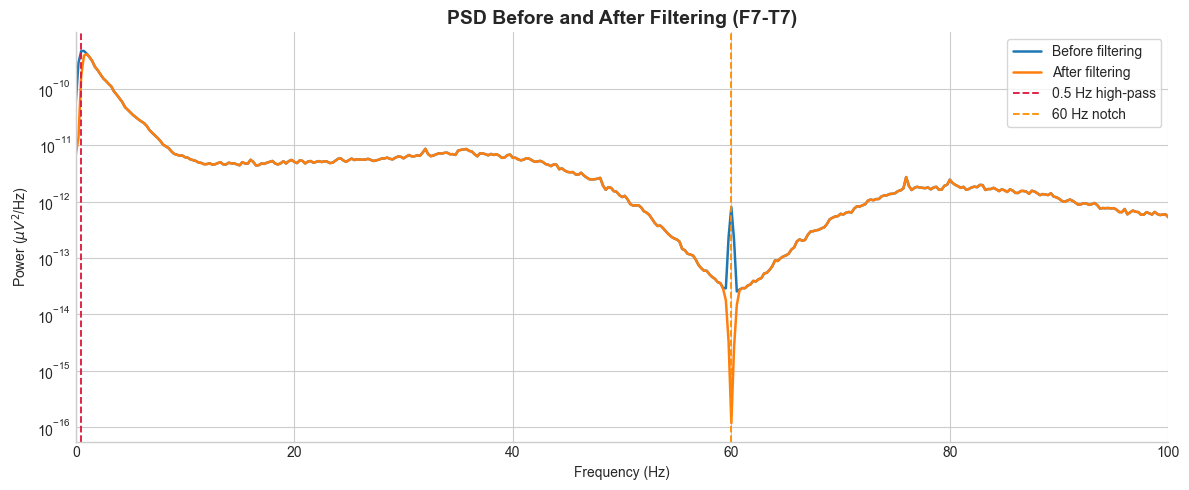

In [3]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.signal import welch

# -----------------------------
# HDF5 loader
# -----------------------------
def load_h5(path):

    with h5py.File(path, "r") as f:

        signals = f["signals"][:]
        fs = f["sampling_rate"][()]
        ch_names = f["channel_names"][:]

    ch_names = [
        c.decode() if isinstance(c, (bytes, bytearray)) else c
        for c in ch_names
    ]

    return signals, fs, ch_names

# -----------------------------
# Load files
# -----------------------------
raw_signals, fs, ch_names = load_h5(
    "../Dataset_hdf5//chb01/chb01_06.h5"
)

filtered_signals, _, _ = load_h5(
    "../Dataset_hdf5_filtered_clean//chb01/chb01_06.h5"
)

# -----------------------------
# Select channel
# -----------------------------
channel_name = "F7-T7"
ch_idx = ch_names.index(channel_name)

raw_signal = raw_signals[ch_idx]
filtered_signal = filtered_signals[ch_idx]

# -----------------------------
# PSD using Welch
# -----------------------------
freqs_raw, psd_raw = welch(
    raw_signal,
    fs=fs,
    nperseg=int(fs * 4)
)

freqs_filt, psd_filt = welch(
    filtered_signal,
    fs=fs,
    nperseg=int(fs * 4)
)

# -----------------------------
# Plot PSD comparison
# -----------------------------
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(12, 5))

# Raw PSD
ax.semilogy(
    freqs_raw,
    psd_raw,
    label="Before filtering",
    linewidth=1.8
)

# Filtered PSD
ax.semilogy(
    freqs_filt,
    psd_filt,
    label="After filtering",
    linewidth=1.8
)

# Filter markers
ax.axvline(
    0.5,
    color="crimson",
    linestyle="--",
    linewidth=1.3,
    label="0.5 Hz high-pass"
)

ax.axvline(
    60,
    color="darkorange",
    linestyle="--",
    linewidth=1.3,
    label="60 Hz notch"
)

# Formatting
ax.set_xlim(0, 100)

ax.set_title(
    f"PSD Before and After Filtering ({channel_name})",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel(r"Power ($\mu V^2$/Hz)")

ax.legend(frameon=True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Filter EDF

In [ ]:


def edf_to_filtered_h5(edf_path, h5_path, highpass=0.5, notch=60):

    # -------------------------
    # 1. Load EDF
    # -------------------------
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    raw.rename_channels(lambda x: x.strip())

    fs = float(raw.info["sfreq"])
    ch_names = np.array(raw.ch_names, dtype="S")

    # -------------------------
    # 2. Filtering (in-place)
    # -------------------------
    raw.filter(
        l_freq=highpass,
        h_freq=None,
        method="iir",
        iir_params=dict(order=4, ftype="butter"),
        phase="zero",
        verbose=False
    )

    raw.notch_filter(
        freqs=notch,
        method="iir",
        phase="zero",
        verbose=False
    )

    # -------------------------
    # 3. Extract filtered signal
    # -------------------------
    data = raw.get_data().astype(np.float32)

    # -------------------------
    # 4. Save to HDF5 (once)
    # -------------------------
    with h5py.File(h5_path, "w") as f:

        f.create_dataset(
            "signals",
            data=data,
            dtype=np.float32,
            compression="gzip",
            compression_opts=4,
            shuffle=False,
            chunks=(data.shape[0], 1024)
        )

        f.create_dataset("sampling_rate", data=fs)
        f.create_dataset("channel_names", data=ch_names)

In [3]:
import glob

input_dir = "../Dataset"
output_dir = "../Dataset_hdf5_filtered"

os.makedirs(output_dir, exist_ok=True)

files = glob.glob(input_dir + "/**/*.edf", recursive=True)

for edf_path in files:

    out_path = edf_path.replace(input_dir, output_dir).replace(".edf", ".h5")
    os.makedirs(os.path.dirname(out_path), exist_ok=True)

    try:
        edf_to_filtered_h5(edf_path, out_path)
        print(f"✓ {os.path.basename(edf_path)}")

    except Exception as e:
        print(f"✗ {edf_path}: {e}")

C:\Users\ritaw\AppData\Local\Temp\ipykernel_15168\1218691552.py:11: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


✓ chb06_01.edf


C:\Users\ritaw\AppData\Local\Temp\ipykernel_15168\1218691552.py:11: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


✓ chb06_02.edf


C:\Users\ritaw\AppData\Local\Temp\ipykernel_15168\1218691552.py:11: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


...

✓ chb24_20.edf


C:\Users\ritaw\AppData\Local\Temp\ipykernel_15168\1218691552.py:11: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


✓ chb24_21.edf


C:\Users\ritaw\AppData\Local\Temp\ipykernel_15168\1218691552.py:11: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


✓ chb24_22.edf


# TUDO

In [1]:
import os
import re
import h5py
import mne
import numpy as np


# =========================================================
# Parse CHB-MIT summary.txt
# =========================================================
def parse_chbmit_summary(summary_path):

    seizures_dict = {}

    with open(summary_path, "r", encoding="latin1") as f:
        text = f.read()

    blocks = text.split("File Name:")

    for block in blocks:

        if ".edf" not in block:
            continue

        # ---------------------------------------------
        # EDF filename extraction
        # ---------------------------------------------
        file_match = re.search(
            r"(chb\d+[a-z]?_\d+\+?\.edf)",
            block
        )

        if not file_match:
            file_match = re.search(
                r"(chb\d+[a-z]?_\d+[^\s]*\.edf)",
                block
            )

        if not file_match:
            continue

        file_name = file_match.group(1)

        seizures = []

        # ---------------------------------------------
        # Numbered seizures
        # ---------------------------------------------
        starts_num = re.findall(
            r"Seizure\s*\d+\s*Start Time:\s*(\d+)",
            block
        )

        ends_num = re.findall(
            r"Seizure\s*\d+\s*End Time:\s*(\d+)",
            block
        )

        if len(starts_num) > 0 and len(ends_num) > 0:

            seizures = [
                (int(s), int(e))
                for s, e in zip(starts_num, ends_num)
            ]

        else:

            # ---------------------------------------------
            # Single seizure format
            # ---------------------------------------------
            start = re.search(
                r"Seizure Start Time:\s*(\d+)",
                block
            )

            end = re.search(
                r"Seizure End Time:\s*(\d+)",
                block
            )

            if start and end:

                seizures = [
                    (
                        int(start.group(1)),
                        int(end.group(1))
                    )
                ]

        seizures_dict[file_name] = seizures

    return seizures_dict


# =========================================================
# EDF -> FILTERED HDF5
# =========================================================
def edf_to_filtered_h5(
    edf_path,
    h5_path,
    seizures_sec,
    highpass=0.5,
    notch=60
):

    # ---------------------------------------------
    # Load EDF
    # ---------------------------------------------
    raw = mne.io.read_raw_edf(
        edf_path,
        preload=True,
        verbose=False
    )

    raw.rename_channels(lambda x: x.strip())

    fs = float(raw.info["sfreq"])
    ch_names = np.array(raw.ch_names, dtype="S")

    # ---------------------------------------------
    # Filtering
    # ---------------------------------------------
    raw.filter(
        l_freq=highpass,
        h_freq=None,
        method="iir",
        iir_params=dict(order=4, ftype="butter"),
        phase="zero",
        verbose=False
    )

    raw.notch_filter(
        freqs=notch,
        method="iir",
        phase="zero",
        verbose=False
    )

    # ---------------------------------------------
    # Extract filtered signal
    # ---------------------------------------------
    data = raw.get_data().astype(np.float32)

    # ---------------------------------------------
    # Convert seizures sec -> samples
    # ---------------------------------------------
    seizures_samples = np.array(
        [
            (int(s * fs), int(e * fs))
            for s, e in seizures_sec
        ],
        dtype=np.int64
    )

    if seizures_samples.size == 0:
        seizures_samples = np.zeros((0, 2), dtype=np.int64)

    # ---------------------------------------------
    # Create output directory
    # ---------------------------------------------
    os.makedirs(
        os.path.dirname(h5_path),
        exist_ok=True
    )

    # ---------------------------------------------
    # Save HDF5
    # ---------------------------------------------
    with h5py.File(h5_path, "w") as f:

        f.create_dataset(
            "signals",
            data=data,
            dtype=np.float32,
            compression="gzip",
            compression_opts=4,
            shuffle=False,
            chunks=(data.shape[0], 1024)
        )

        f.create_dataset(
            "sampling_rate",
            data=fs
        )

        f.create_dataset(
            "channel_names",
            data=ch_names
        )

        f.create_dataset(
            "seizure_intervals",
            data=seizures_samples
        )

    print(f"✓ Saved → {h5_path}")


# =========================================================
# Batch processing
# =========================================================
def convert_dataset_filtered(
    seizure_map,
    DATASET_PATH,
    OUTPUT_PATH
):

    for file_name, seizures_sec in seizure_map.items():

        edf_path = os.path.join(
            DATASET_PATH,
            file_name
        )

        if not os.path.exists(edf_path):
            print(f"Missing: {edf_path}")
            continue

        h5_path = os.path.join(
            OUTPUT_PATH,
            file_name.replace(".edf", ".h5")
        )

        try:

            edf_to_filtered_h5(
                edf_path=edf_path,
                h5_path=h5_path,
                seizures_sec=seizures_sec
            )

        except Exception as e:

            print(f"✗ Error {file_name}: {e}")

In [2]:
nums = [f"{i:02d}" for i in range(4, 25)]

for numero in nums:

    # -------------------------------------------------
    # Summary file
    # -------------------------------------------------
    summary_path = f"../Dataset/chb{numero}/chb{numero}-summary.txt"

    seizure_map = parse_chbmit_summary(summary_path)

    print(f"\nProcessing patient chb{numero}")

    # -------------------------------------------------
    # Input / output folders
    # -------------------------------------------------
    DATASET_PATH = f"../Dataset/chb{numero}"
    OUTPUT_PATH = f"../Dataset_hdf5_filtered/chb{numero}"

    os.makedirs(OUTPUT_PATH, exist_ok=True)

    # -------------------------------------------------
    # Run filtered conversion
    # -------------------------------------------------
    convert_dataset_filtered(
        seizure_map=seizure_map,
        DATASET_PATH=DATASET_PATH,
        OUTPUT_PATH=OUTPUT_PATH
    )


Processing patient chb04


C:\Users\ritaw\AppData\Local\Temp\ipykernel_18596\1560163123.py:109: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


✓ Saved → ../Dataset_hdf5_filtered/chb04\chb04_01.h5


C:\Users\ritaw\AppData\Local\Temp\ipykernel_18596\1560163123.py:109: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


✓ Saved → ../Dataset_hdf5_filtered/chb04\chb04_02.h5


...

✓ Saved → ../Dataset_hdf5_filtered/chb24\chb24_20.h5


C:\Users\ritaw\AppData\Local\Temp\ipykernel_18596\1560163123.py:109: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


✓ Saved → ../Dataset_hdf5_filtered/chb24\chb24_21.h5


C:\Users\ritaw\AppData\Local\Temp\ipykernel_18596\1560163123.py:109: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


✓ Saved → ../Dataset_hdf5_filtered/chb24\chb24_22.h5
